# One Week Tutorial Model

In [4]:
import pypsa
import matplotlib.pyplot as plt


In [5]:
n = pypsa.Network("/data/PyPSA-GH/results/networks/elec_s_6_ec_lcopt_Co2L-4H.nc")

INFO:pypsa.io:Imported network elec_s_6_ec_lcopt_Co2L-4H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [6]:
print(f"Buses: {len(n.buses)}")
print(f"Generators: {len(n.generators)}")
print(f"Lines: {len(n.lines)}")

Buses: 21
Generators: 45
Lines: 6


Generation Mix in Ghana

In [11]:
cap = n.generators.groupby("carrier")["p_nom_opt"].sum().sort_values(ascending=False)

In [12]:
print("\n=== Optimal capacity (MW) ===")
print(cap.round(1))


=== Optimal capacity (MW) ===
carrier
onwind           15438.5
solar             6897.4
load shedding     3586.1
CCGT              3582.2
oil                879.5
offwind-ac           0.0
offwind-dc           0.0
Name: p_nom_opt, dtype: float64


/home/kduah/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


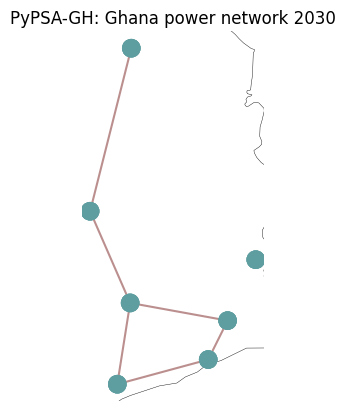

In [14]:
n.plot(title="PyPSA-GH: Ghana power network 2030")
plt.savefig("ghana_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Check all generators including fixed capacity
print("=== All generators ===")
print(n.generators[["carrier", "p_nom", "p_nom_opt", "p_nom_extendable"]].to_string())

# Check storage units (hydro may be there)
print("\n=== Storage units ===")
print(n.storage_units[["carrier", "p_nom", "p_nom_opt"]].groupby("carrier").sum().round(1))

=== All generators ===
                                   carrier        p_nom    p_nom_opt  p_nom_extendable
Generator                                                                             
GH0 0 CCGT                            CCGT  1817.154566  1817.154566             False
GH0 0 offwind-ac                offwind-ac     0.000000    -0.000000              True
GH0 0 offwind-dc                offwind-dc     0.000000    -0.000000              True
GH0 0 oil                              oil   370.000000   370.000000             False
GH0 0 onwind                        onwind     0.002697  9187.026533              True
GH0 0 solar                          solar    61.800000   749.389002              True
GH0 1 onwind                        onwind     0.003596    -0.000000              True
GH0 1 solar                          solar   253.200000   253.200000              True
GH0 2 CCGT                            CCGT  1765.000000  1765.000000             False
GH0 2 offwind-ac    

In [16]:
print(n.generators.groupby("carrier")["p_nom"].sum().round(1))

carrier
CCGT             3582.2
load shedding    3586.1
offwind-ac          0.0
offwind-dc          0.0
oil               879.5
onwind              0.0
solar             548.8
Name: p_nom, dtype: float64


In [17]:
# Real Ghana numbers to compare against
irena_2022 = {
    "hydro": 1584,
    "CCGT": 3582,
    "oil": 880,
    "solar": 549,
}

pypsa_existing = n.generators.groupby("carrier")["p_nom"].sum()
pypsa_existing["hydro"] = n.storage_units.groupby("carrier")["p_nom"].sum()["hydro"]

import pandas as pd
comparison = pd.DataFrame({
    "PyPSA (MW)": pypsa_existing,
    "IRENA 2022 (MW)": pd.Series(irena_2022)
}).dropna()
comparison["Error %"] = ((comparison["PyPSA (MW)"] - comparison["IRENA 2022 (MW)"]) 
                          / comparison["IRENA 2022 (MW)"] * 100).round(1)
print(comparison)

        PyPSA (MW)  IRENA 2022 (MW)  Error %
CCGT   3582.154566           3582.0      0.0
hydro  1584.000000           1584.0      0.0
oil     879.484522            880.0     -0.1
solar   548.800000            549.0     -0.0


In [18]:
import pandas as pd

# Load your IRENA file
irena = pd.read_excel(
    "/data/PyPSA-GH/data/IRENA_Statistics_Extract_2025H2.xlsx",
    sheet_name=None  # see all sheets first
)
print(list(irena.keys()))

['About', 'Pivot', 'Country', 'Region ', 'Global']


In [19]:
# Look at first sheet
sheet = list(irena.keys())[0]
df = irena[sheet]
print(df.head(20))
print(df.columns.tolist())

  IRENA (2025), Renewable Energy Statistics 2025, International Renewable Energy Agency, Abu Dhabi.
0  https://www.irena.org/Publications/2025/Jul/Re...                                               
['IRENA (2025), Renewable Energy Statistics 2025, International Renewable Energy Agency, Abu Dhabi.']


In [20]:
df = irena['Pivot']
print(df.shape)
print(df.columns.tolist())
print(df.head(10).to_string())

(91746, 17)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']
  Unnamed: 0 Unnamed: 1 Unnamed: 2 Unnamed: 3       Unnamed: 4 Unnamed: 5       Unnamed: 6                         Unnamed: 7            Unnamed: 8                           Unnamed: 9           Unnamed: 10                                 Unnamed: 11                          Unnamed: 12                  Unnamed: 13                       Unnamed: 14                                     Unnamed: 15                                           Unnamed: 16
0        NaN        NaN        NaN        NaN              NaN        NaN              NaN                                NaN                   NaN                                  NaN                   NaN                                         NaN                                  NaN  

In [21]:
# Fix headers
df.columns = df.iloc[1]
df = df.iloc[2:].reset_index(drop=True)

# Filter Ghana, most recent year, on-grid electricity, installed capacity
ghana = df[
    (df['Country'] == 'Ghana') &
    (df['Year'] == df[df['Country'] == 'Ghana']['Year'].max()) &
    (df['Producer Type'] == 'On-grid electricity')
][['Year', 'Group Technology', 'Technology', 'Sum of Electricity Installed Capacity (MW)']].dropna(
    subset=['Sum of Electricity Installed Capacity (MW)']
)

ghana['Sum of Electricity Installed Capacity (MW)'] = pd.to_numeric(
    ghana['Sum of Electricity Installed Capacity (MW)'], errors='coerce'
)

print(ghana.to_string())

1      Year                   Group Technology            Technology  Sum of Electricity Installed Capacity (MW)
32810  2024                          Bioenergy                Biogas                                       0.100
32812  2024  Hydropower (excl. Pumped Storage)  Renewable hydropower                                    1584.045
32814  2024                       Solar energy    Solar photovoltaic                                     173.363
32816  2024                       Fossil fuels                   Oil                                     370.000
32817  2024                       Fossil fuels           Natural gas                                    3743.500


In [22]:
# IRENA Ghana 2024
irena_ghana = {
    "hydro": 1584.0,
    "solar": 173.4,
    "oil": 370.0,
    "CCGT": 3743.5,  # natural gas
    "biogas": 0.1,
}

# PyPSA existing capacity
pypsa = {
    "hydro": n.storage_units.groupby("carrier")["p_nom"].sum().get("hydro", 0),
    "solar": n.generators.groupby("carrier")["p_nom"].sum().get("solar", 0),
    "oil": n.generators.groupby("carrier")["p_nom"].sum().get("oil", 0),
    "CCGT": n.generators.groupby("carrier")["p_nom"].sum().get("CCGT", 0),
}

comparison = pd.DataFrame({
    "PyPSA-GH (MW)": pd.Series(pypsa),
    "IRENA 2024 (MW)": pd.Series(irena_ghana),
}).dropna()

comparison["Difference (MW)"] = (comparison["PyPSA-GH (MW)"] - comparison["IRENA 2024 (MW)"]).round(1)
comparison["Error (%)"] = ((comparison["Difference (MW)"] / comparison["IRENA 2024 (MW)"]) * 100).round(1)

print("=== PyPSA-GH vs IRENA 2024 — Ghana Installed Capacity ===")
print(comparison.round(1).to_string())
print(f"\nTotal PyPSA: {comparison['PyPSA-GH (MW)'].sum():.0f} MW")
print(f"Total IRENA: {comparison['IRENA 2024 (MW)'].sum():.0f} MW")
print(f"Total Error: {((comparison['PyPSA-GH (MW)'].sum() - comparison['IRENA 2024 (MW)'].sum()) / comparison['IRENA 2024 (MW)'].sum() * 100):.1f}%")

=== PyPSA-GH vs IRENA 2024 — Ghana Installed Capacity ===
       PyPSA-GH (MW)  IRENA 2024 (MW)  Difference (MW)  Error (%)
CCGT          3582.2           3743.5           -161.3       -4.3
hydro         1584.0           1584.0              0.0        0.0
oil            879.5            370.0            509.5      137.7
solar          548.8            173.4            375.4      216.5

Total PyPSA: 6594 MW
Total IRENA: 5871 MW
Total Error: 12.3%


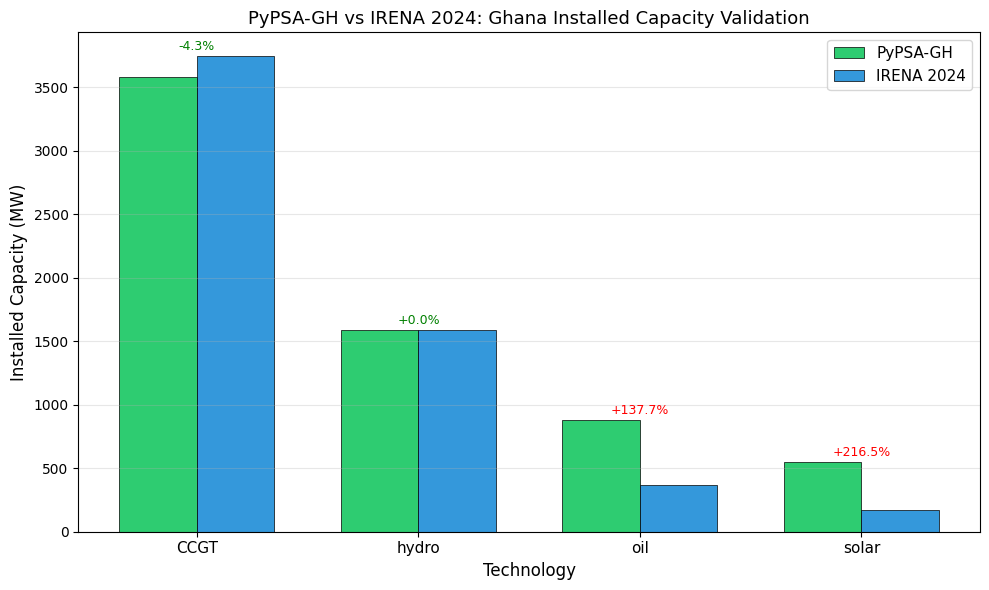

Saved to notebooks/validation_irena_2024.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison["PyPSA-GH (MW)"], width, 
               label="PyPSA-GH", color="#2ecc71", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, comparison["IRENA 2024 (MW)"], width, 
               label="IRENA 2024", color="#3498db", edgecolor="black", linewidth=0.5)

ax.set_xlabel("Technology", fontsize=12)
ax.set_ylabel("Installed Capacity (MW)", fontsize=12)
ax.set_title("PyPSA-GH vs IRENA 2024: Ghana Installed Capacity Validation", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=11)
ax.legend(fontsize=11)

# Add error % labels
for i, (idx, row) in enumerate(comparison.iterrows()):
    ax.annotate(f"{row['Error (%)']:+.1f}%", 
                xy=(i, max(row["PyPSA-GH (MW)"], row["IRENA 2024 (MW)"]) + 50),
                ha='center', fontsize=9, color='red' if abs(row['Error (%)']) > 20 else 'green')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/data/PyPSA-GH/notebooks/validation_irena_2024.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to notebooks/validation_irena_2024.png")